# **Reconstruction: Active and Volumetric Stereo**
Dingjiang Liang

# Passive Stereo

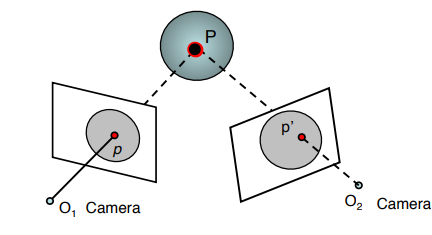
---

## Basic Idea

Passive stereo uses **two cameras** to reconstruct a 3D point from its two image projections.

---

## Stereo Depth Equation

The **disparity** is defined as:

$$
d = x_L - x_R
$$

The depth is computed by:

$$
Z = \frac{fB}{d}
$$

where:

$$
d = \text{disparity}, \quad
f = \text{focal length}, \quad
B = \text{camera baseline}
$$

---

## Problem in Traditional Stereo

Traditional stereo only uses two cameras to estimate 3D points.

The main difficulty is the **correspondence problem**:

> We need to find which point in image 1 matches which point in image 2.

---

## Limitation

Matching becomes difficult when the surface is:

- textureless
- repetitive
- dark

# Active Stereo


Active stereo is a 3D reconstruction method that uses an active light source to help recover depth.

Instead of relying only on natural image texture, active stereo projects known light onto the object.

The projected light can be:

- a single point
- a stripe
- a coded pattern

These artificial features make 3D reconstruction easier and more reliable.

# Active Stereo: Point

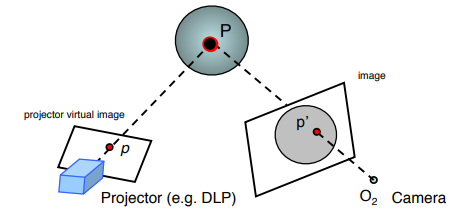

---

## Idea

Project a **single point** onto the object.

The camera observes this point and reconstructs one 3D position.

---

## Geometry

$$
\text{camera ray} \cap \text{projector ray}
=
\text{one 3D point}
$$

---

## Limitation

- Slow reconstruction
- Sensitive to noise and reflection
- Only one point is recovered at a time
- No full-surface reconstruction from one image

# 3D Projector Ray

A projected point forms a 3D ray from the projector center.

The camera observes the projected point at:

$$
\mathbf{x}_c =
\begin{bmatrix}
u_c\\
v_c\\
1
\end{bmatrix}
$$

The projector emits the point from:

$$
\mathbf{x}_p =
\begin{bmatrix}
u_p\\
v_p\\
1
\end{bmatrix}
$$

Back-project the camera pixel into a camera ray:

$$
\mathbf{r}_c = K_c^{-1}\mathbf{x}_c
$$

So the 3D point lies on:

$$
\mathbf{X} = \lambda_c \mathbf{r}_c
$$

Back-project the projector pixel into a projector ray:

$$
\mathbf{r}_p = K_p^{-1}\mathbf{x}_p
$$

If the projector pose relative to the camera is:

$$
\mathbf{X}_p = R\mathbf{X}_c + \mathbf{t}
$$

then the projector center in the camera coordinate system is:

$$
\mathbf{C}_p = -R^T\mathbf{t}
$$

and the projector ray direction in the camera coordinate system is:

$$
\mathbf{d}_p = R^T\mathbf{r}_p
$$

Therefore, the projector ray is:

$$
\mathbf{X} = \mathbf{C}_p + \lambda_p \mathbf{d}_p
$$

# Ray-Ray Intersection

A single projected point gives two rays:

Camera ray:

$$
\mathbf{X} = \lambda_c \mathbf{r}_c
$$

Projector ray:

$$
\mathbf{X} = \mathbf{C}_p + \lambda_p \mathbf{d}_p
$$

The 3D point is recovered by finding the intersection of these two rays:

$$
\lambda_c \mathbf{r}_c
=
\mathbf{C}_p + \lambda_p \mathbf{d}_p
$$

Rearrange:

$$
\lambda_c \mathbf{r}_c - \lambda_p \mathbf{d}_p
=
\mathbf{C}_p
$$

Matrix form:

$$
\begin{bmatrix}
\mathbf{r}_c & -\mathbf{d}_p
\end{bmatrix}
\begin{bmatrix}
\lambda_c\\
\lambda_p
\end{bmatrix}
=
\mathbf{C}_p
$$

After solving for lambda_c and lambda_p, the reconstructed 3D point is:

$$
\mathbf{X} = \lambda_c \mathbf{r}_c
$$

In practice, because of noise, the two rays may not exactly intersect.  
So we solve the least-squares problem:

$$
\min_{\lambda_c,\lambda_p}
\left\|
\lambda_c\mathbf{r}_c -
\left(
\mathbf{C}_p+\lambda_p\mathbf{d}_p
\right)
\right\|^2
$$

Then we take the midpoint of the closest points on the two rays:

$$
\mathbf{X}
=
\frac{1}{2}
\left[
\lambda_c\mathbf{r}_c
+
\left(
\mathbf{C}_p+\lambda_p\mathbf{d}_p
\right)
\right]
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(v):
    return v / np.linalg.norm(v)

# Camera intrinsic matrix
Kc = np.array([
    [800,   0, 320],
    [  0, 800, 240],
    [  0,   0,   1]
], dtype=float)

# Projector intrinsic matrix
Kp = np.array([
    [800,   0, 320],
    [  0, 800, 240],
    [  0,   0,   1]
], dtype=float)

# Projector pose relative to camera
# X_p = R X_c + t
R = np.eye(3)

# Projector is shifted 0.2 meters to the right of the camera
t = np.array([-0.2, 0.0, 0.0])

# Camera observes the projected dot at this pixel
xc = np.array([350, 240, 1], dtype=float)

# Projector emits the dot from this pixel
xp = np.array([300, 240, 1], dtype=float)

# Camera ray
rc = np.linalg.inv(Kc) @ xc
rc = normalize(rc)

# Projector ray in projector coordinate
rp = np.linalg.inv(Kp) @ xp
rp = normalize(rp)

# Projector center in camera coordinate
Cp = -R.T @ t

# Projector ray direction in camera coordinate
dp = R.T @ rp
dp = normalize(dp)

print("Camera ray direction:")
print(rc)

print("\nProjector center:")
print(Cp)

print("\nProjector ray direction:")
print(dp)

Camera ray direction:
[0.03747366 0.         0.99929762]

Projector center:
[0.2 0.  0. ]

Projector ray direction:
[-0.02499219  0.          0.99968765]


In [ ]:
# Solve:
# lambda_c * rc - lambda_p * dp = Cp

A = np.column_stack([rc, -dp])
b = Cp

lambdas, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

lambda_c = lambdas[0]
lambda_p = lambdas[1]

# Closest point on camera ray
X_camera_ray = lambda_c * rc

# Closest point on projector ray
X_projector_ray = Cp + lambda_p * dp

# Final reconstructed 3D point
X = 0.5 * (X_camera_ray + X_projector_ray)

print("lambda_c:", lambda_c)
print("lambda_p:", lambda_p)

print("\nClosest point on camera ray:")
print(X_camera_ray)

print("\nClosest point on projector ray:")
print(X_projector_ray)

print("\nReconstructed 3D point:")
print(X)

lambda_c: 3.202249209540066
lambda_p: 3.200999843798806

Closest point on camera ray:
[0.12 0.   3.2 ]

Closest point on projector ray:
[0.12 0.   3.2 ]

Reconstructed 3D point:
[0.12 0.   3.2 ]


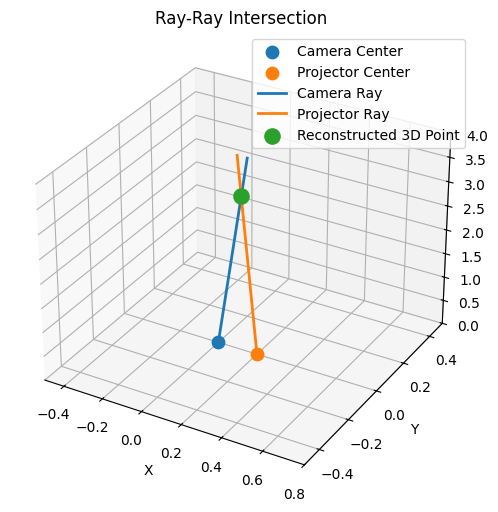

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Ray lengths
s_vals = np.linspace(0, 4, 100)

# Camera ray points
camera_ray_points = np.array([s * rc for s in s_vals])

# Projector ray points
projector_ray_points = np.array([Cp + s * dp for s in s_vals])

# Plot camera center
ax.scatter(0, 0, 0, s=80, label="Camera Center")

# Plot projector center
ax.scatter(Cp[0], Cp[1], Cp[2], s=80, label="Projector Center")

# Plot rays
ax.plot(
    camera_ray_points[:, 0],
    camera_ray_points[:, 1],
    camera_ray_points[:, 2],
    linewidth=2,
    label="Camera Ray"
)

ax.plot(
    projector_ray_points[:, 0],
    projector_ray_points[:, 1],
    projector_ray_points[:, 2],
    linewidth=2,
    label="Projector Ray"
)

# Plot reconstructed 3D point
ax.scatter(
    X[0], X[1], X[2],
    s=120,
    label="Reconstructed 3D Point"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Ray-Ray Intersection")

ax.set_xlim(-0.5, 0.8)
ax.set_ylim(-0.5, 0.5)
ax.set_zlim(0, 4)

ax.legend()
plt.show()

# Active Stereo: Stripe
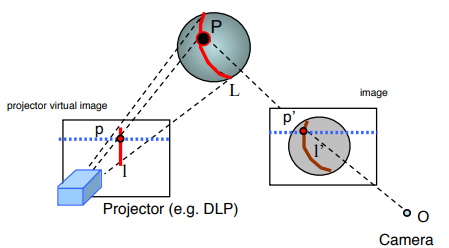

## Idea

A stripe is projected onto the object surface.

In 3D, the stripe is a light plane.

## Geometry

$$
\text{camera ray} \cap \text{light plane}
=
\text{one 3D point}
$$

One stripe contains many bright pixels, so one image can reconstruct many 3D points along a curve.

# 3D Light Plane

A projected stripe forms a 3D light plane.

The plane equation is:

$$
ax + by + cz + d = 0
$$

or:

$$
\boldsymbol{\pi}^T \mathbf{X} = 0
$$

where:

$$
\boldsymbol{\pi} = (a,b,c,d)^T
$$

and:

$$
\mathbf{X} = (x,y,z,1)^T
$$

# Ray-Plane Intersection

Each bright pixel on the stripe defines a camera ray:

$$
\mathbf{X}(\lambda)
=
\mathbf{C}
+
\lambda \mathbf{r}
$$

The stripe defines a light plane:

$$
\mathbf{n}^T\mathbf{X} + d = 0
$$

Substitute the ray into the plane equation:

$$
\mathbf{n}^T(\mathbf{C}+\lambda\mathbf{r}) + d = 0
$$

Solve for $\lambda$:

$$
\lambda
=
-\frac{\mathbf{n}^T\mathbf{C}+d}
{\mathbf{n}^T\mathbf{r}}
$$

Then:

$$
\mathbf{X}
=
\mathbf{C}
+
\lambda\mathbf{r}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Camera center
C = np.array([0.0, 0.0, 0.0])

# Simulated bright pixels on a stripe in camera image
u_values = np.linspace(-1.0, 1.0, 25)
v_values = 0.25 * np.sin(3 * u_values)

# Convert each image pixel into a camera ray direction
rays = []

for u, v in zip(u_values, v_values):
    r = np.array([u, v, 1.0])
    r = r / np.linalg.norm(r)
    rays.append(r)

rays = np.array(rays)

# Define the projected stripe as a 3D light plane
# Plane equation: n^T X + d = 0
n = np.array([-0.4, -0.15, 1.0])
n = n / np.linalg.norm(n)
d = -3.0

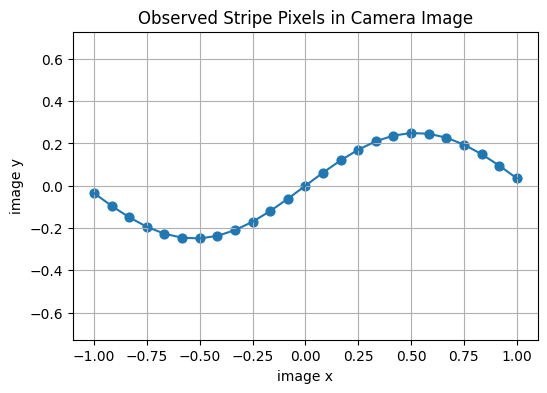

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(u_values, v_values, s=40)
plt.plot(u_values, v_values)

plt.xlabel("image x")
plt.ylabel("image y")
plt.title("Observed Stripe Pixels in Camera Image")
plt.grid(True)
plt.axis("equal")
plt.show()

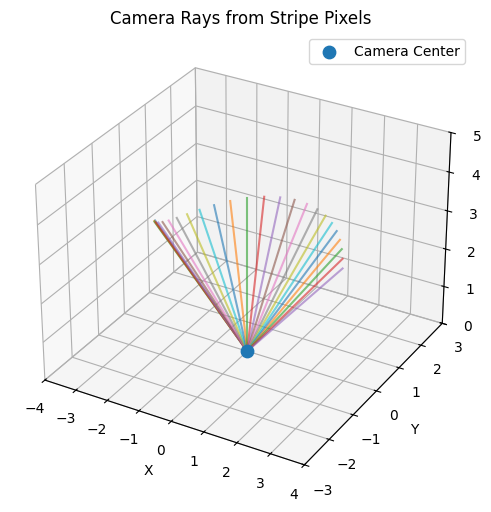

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[0], C[1], C[2], s=80, label="Camera Center")

ray_length = 4.0

for r in rays:
    end = C + ray_length * r
    ax.plot(
        [C[0], end[0]],
        [C[1], end[1]],
        [C[2], end[2]],
        alpha=0.6
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Camera Rays from Stripe Pixels")

ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 5)
ax.legend()
plt.show()

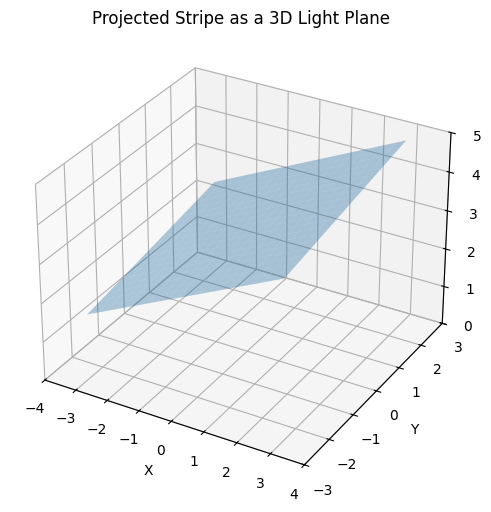

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

xx, yy = np.meshgrid(
    np.linspace(-3, 3, 20),
    np.linspace(-2.5, 2.5, 20)
)

zz = -(n[0] * xx + n[1] * yy + d) / n[2]

ax.plot_surface(xx, yy, zz, alpha=0.35)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Projected Stripe as a 3D Light Plane")

ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 5)
plt.show()

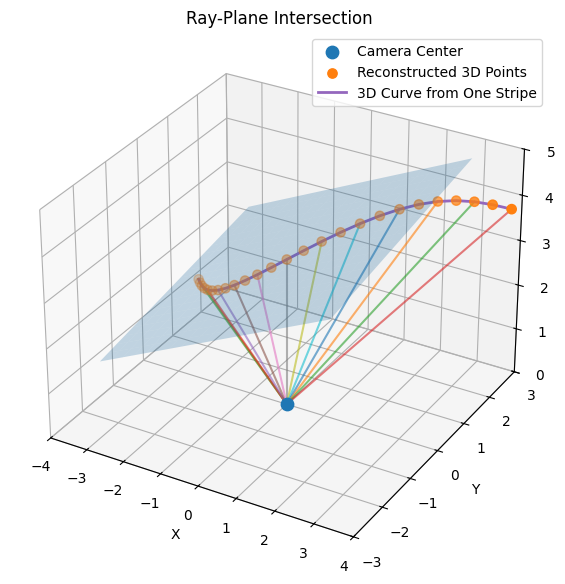

In [ ]:
points_3d = []

for r in rays:
    # Ray-plane intersection
    # X(lambda) = C + lambda r
    # n^T X + d = 0
    lam = -(np.dot(n, C) + d) / np.dot(n, r)
    X = C + lam * r
    points_3d.append(X)

points_3d = np.array(points_3d)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot light plane
xx, yy = np.meshgrid(
    np.linspace(-3, 3, 20),
    np.linspace(-2.5, 2.5, 20)
)
zz = -(n[0] * xx + n[1] * yy + d) / n[2]
ax.plot_surface(xx, yy, zz, alpha=0.25)

# Plot camera center
ax.scatter(C[0], C[1], C[2], s=80, label="Camera Center")

# Plot camera rays
for X in points_3d[::2]:
    ax.plot(
        [C[0], X[0]],
        [C[1], X[1]],
        [C[2], X[2]],
        alpha=0.6
    )

# Plot reconstructed 3D points
ax.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    s=45,
    label="Reconstructed 3D Points"
)

ax.plot(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    linewidth=2,
    label="3D Curve from One Stripe"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Ray-Plane Intersection")

ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)
ax.set_zlim(0, 5)
ax.legend()
plt.show()

# Structured Light: Color-Coded Stripes
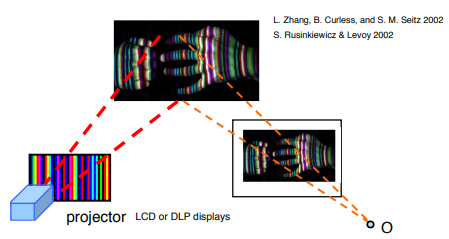

Color-coded stripes project multiple colored stripes onto the object.

The camera decodes the color pattern to find correspondence:

$$
\mathbf{x}_c \leftrightarrow \mathbf{x}_p
$$

Then the 3D point is reconstructed by triangulation:

$$
\mathbf{X}
=
\text{Triangulate}
(\mathbf{x}_c,\mathbf{x}_p,\mathbf{P}_c,\mathbf{P}_p)
$$

In [ ]:
import sys

!{sys.executable} -m pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!{sys.executable} -m pip install -q opencv-contrib-python-headless

import os
os.kill(os.getpid(), 9)

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 11.4 MB/s eta 0:00:00


In [ ]:
import os
import re
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

print("OpenCV version:", cv2.__version__)
print("Has structured_light:", hasattr(cv2, "structured_light"))

if not hasattr(cv2, "structured_light"):
    raise RuntimeError("structured_light module not found.")

OpenCV version: 4.13.0
Has structured_light: True


In [ ]:
!wget -q https://github.com/opencv/opencv_extra/archive/refs/heads/4.x.zip -O opencv_extra.zip
!unzip -q -o opencv_extra.zip

DATA_DIR = "/content/opencv_extra-4.x/testdata/cv/structured_light/data"
CALIB_PATH = os.path.join(DATA_DIR, "calibrationParameters.yml")

print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("CALIB_PATH exists:", os.path.exists(CALIB_PATH))
print(os.listdir(DATA_DIR)[:10])

^C
[opencv_extra.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of opencv_extra.zip or
        opencv_extra.zip.zip, and cannot find opencv_extra.zip.ZIP, period.
DATA_DIR exists: True
CALIB_PATH exists: True
['pattern_cam2_im8.jpg', 'pattern_cam1_im14.jpg', 'pattern_cam1_im9.jpg', 'pattern_cam2_im2.jpg', 'pattern_cam1_im26.jpg', 'pattern_cam2_im38.jpg', 'pattern_cam2_im43.jpg', 'pattern_cam2_im25.jpg', 'calibrationParameters.yml', 'capture_sin_1.jpg']


In [ ]:
fs = cv2.FileStorage(CALIB_PATH, cv2.FILE_STORAGE_READ)

cam1_K = fs.getNode("cam1_intrinsics").mat()
cam2_K = fs.getNode("cam2_intrinsics").mat()
cam1_dist = fs.getNode("cam1_distorsion").mat()
cam2_dist = fs.getNode("cam2_distorsion").mat()
R = fs.getNode("R").mat()
T = fs.getNode("T").mat()

fs.release()

print("cam1_K:\n", cam1_K)
print("cam2_K:\n", cam2_K)
print("cam1_dist:\n", cam1_dist)
print("cam2_dist:\n", cam2_dist)
print("R:\n", R)
print("T:\n", T)

if cam1_K is None or cam2_K is None or cam1_dist is None or cam2_dist is None or R is None or T is None:
    raise RuntimeError("Failed to load calibration parameters.")

cam1_K:
 [[2.96496155e+03 0.00000000e+00 1.00298841e+03]
 [0.00000000e+00 2.97264038e+03 8.32401094e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
cam2_K:
 [[2.96496155e+03 0.00000000e+00 1.01007102e+03]
 [0.00000000e+00 2.97264038e+03 8.30369870e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
cam1_dist:
 [[-0.10169992  0.05979991  0.01169174  0.00128601 -0.02159428]]
cam2_dist:
 [[ 5.19918848e-02 -1.81848061e+00  1.93922883e-02  6.58193739e-03
   9.58603125e+00]]
R:
 [[ 0.88369962 -0.00433231  0.46803441]
 [ 0.02596698  0.9988709  -0.03978253]
 [-0.4673336   0.04730924  0.88281433]]
T:
 [[-1545.96703924]
 [   24.47528257]
 [  385.53130173]]


cam1 pattern images: 44
cam2 pattern images: 44
Image size: (1920, 1280)


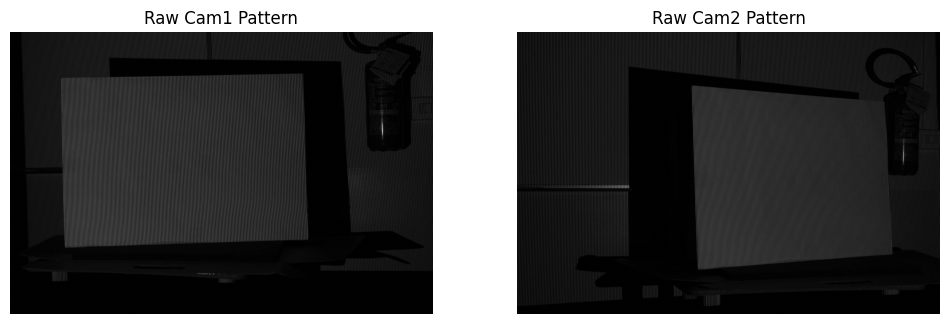

In [ ]:
def sort_by_number(path):
    name = os.path.basename(path)
    number = int(re.findall(r"im(\d+)", name)[0])
    return number

cam1_paths = sorted(glob.glob(os.path.join(DATA_DIR, "pattern_cam1_im*.jpg")), key=sort_by_number)
cam2_paths = sorted(glob.glob(os.path.join(DATA_DIR, "pattern_cam2_im*.jpg")), key=sort_by_number)

print("cam1 pattern images:", len(cam1_paths))
print("cam2 pattern images:", len(cam2_paths))

def load_gray_images(paths):
    imgs = []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"Failed to read image: {p}")
        imgs.append(np.ascontiguousarray(img.astype(np.uint8)))
    return imgs

cam1_raw = load_gray_images(cam1_paths)
cam2_raw = load_gray_images(cam2_paths)

H, W = cam1_raw[0].shape
image_size = (W, H)

print("Image size:", image_size)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cam1_raw[21], cmap="gray")
plt.title("Raw Cam1 Pattern")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam2_raw[21], cmap="gray")
plt.title("Raw Cam2 Pattern")
plt.axis("off")

plt.show()

In [ ]:
projector_width = 1920
projector_height = 1080

graycode = cv2.structured_light.GrayCodePattern_create(
    projector_width,
    projector_height
)

numberOfPatternImages = graycode.getNumberOfPatternImages()

print("Expected pattern images:", numberOfPatternImages)
print("Actual cam1 images:", len(cam1_raw))
print(
"Actual cam2 images:", len(cam2_raw))

if len(cam1_raw) != numberOfPatternImages or len(cam2_raw) != numberOfPatternImages:
    raise RuntimeError("Pattern image number mismatch.")

white_thresh = 5
black_thresh = 40

graycode.setWhiteThreshold(white_thresh)
graycode.setBlackThreshold(black_thresh)

Expected pattern images: 44
Actual cam1 images: 44
Actual cam2 images: 44


In [ ]:
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    cam1_K,
    cam1_dist,
    cam2_K,
    cam2_dist,
    image_size,
    R,
    T,
    flags=0,
    alpha=-1
)

map1x, map1y = cv2.initUndistortRectifyMap(
    cam1_K,
    cam1_dist,
    R1,
    P1,
    image_size,
    cv2.CV_32FC1
)

map2x, map2y = cv2.initUndistortRectifyMap(
    cam2_K,
    cam2_dist,
    R2,
    P2,
    image_size,
    cv2.CV_32FC1
)

print("Q matrix:\n", Q)

Q matrix:
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.77811676e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -8.49252071e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.97264038e+03]
 [ 0.00000000e+00  0.00000000e+00  6.27548769e-04  1.04272944e+00]]


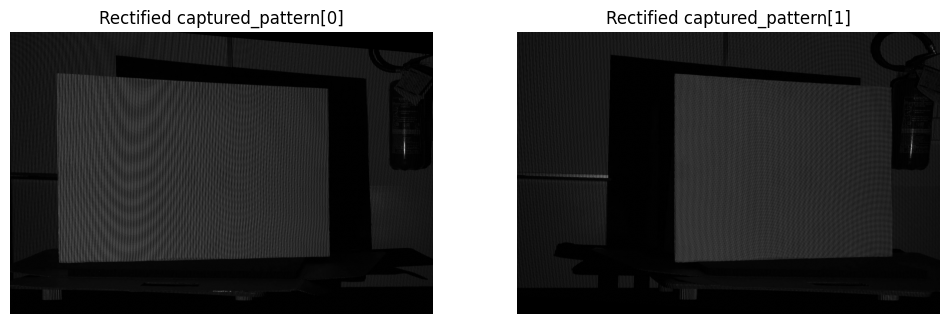

In [ ]:
captured_pattern = [[], []]

for i in range(numberOfPatternImages):
    img0 = cam1_raw[i].copy()
    img1 = cam2_raw[i].copy()

    # Official-style remap order:
    # captured_pattern[1] uses map1
    # captured_pattern[0] uses map2
    rect1 = cv2.remap(
        img1,
        map1x,
        map1y,
        cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    rect0 = cv2.remap(
        img0,
        map2x,
        map2y,
        cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    captured_pattern[0].append(np.ascontiguousarray(rect0.astype(np.uint8)))
    captured_pattern[1].append(np.ascontiguousarray(rect1.astype(np.uint8)))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(captured_pattern[0][21], cmap="gray")
plt.title("Rectified captured_pattern[0]")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(captured_pattern[1][21], cmap="gray")
plt.title("Rectified captured_pattern[1]")
plt.axis("off")

plt.show()

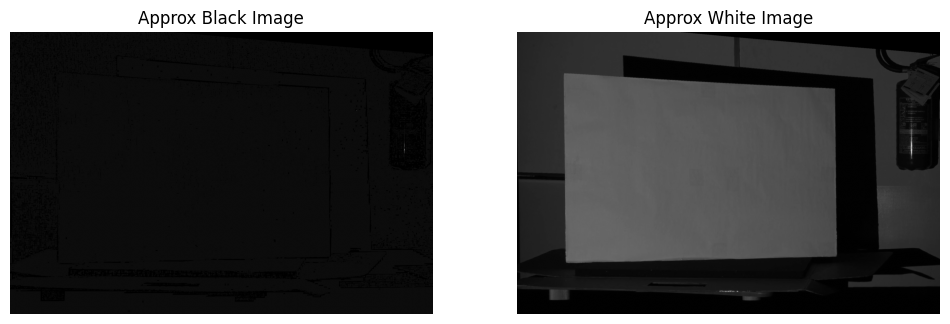

In [ ]:
def make_black_white_from_sequence(imgs):
    stack = np.stack([img.astype(np.uint8) for img in imgs], axis=0)
    black = np.min(stack, axis=0).astype(np.uint8)
    white = np.max(stack, axis=0).astype(np.uint8)
    return black, white

# Generate from already-rectified captured patterns
black0, white0 = make_black_white_from_sequence(captured_pattern[0])
black1, white1 = make_black_white_from_sequence(captured_pattern[1])

blackImages = [
    np.ascontiguousarray(black0),
    np.ascontiguousarray(black1)
]

whiteImages = [
    np.ascontiguousarray(white0),
    np.ascontiguousarray(white1)
]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(blackImages[0], cmap="gray")
plt.title("Approx Black Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(whiteImages[0], cmap="gray")
plt.title("Approx White Image")
plt.axis("off")

plt.show()

In [ ]:
print("Decoding pattern...")

decoded, disparityMap = graycode.decode(
    captured_pattern,
    None,
    blackImages,
    whiteImages,
    cv2.structured_light.DECODE_3D_UNDERWORLD
)

print("Decoded:", decoded)

if not decoded:
    raise RuntimeError("Gray-code decode failed.")

disparityMap = disparityMap.astype(np.float32)

print("Disparity shape:", disparityMap.shape)
print("Disparity min:", np.nanmin(disparityMap))
print("Disparity max:", np.nanmax(disparityMap))

Decoding pattern...
Decoded: True
Disparity shape: (1280, 1920)
Disparity min: -95.666664
Disparity max: 504.16666


disp min: 17.0
disp max: 504.1666564941406


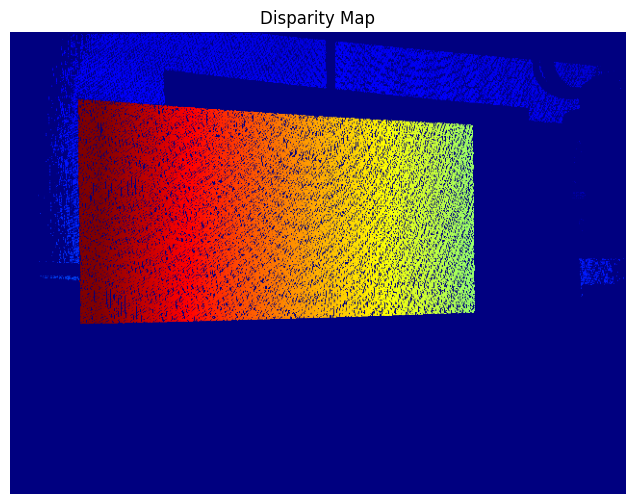

In [ ]:
valid = disparityMap > 0

min_val = float(np.min(disparityMap[valid]))
max_val = float(np.max(disparityMap[valid]))

print("disp min:", min_val)
print("disp max:", max_val)

scaledDisparityMap = cv2.convertScaleAbs(
    disparityMap,
    alpha=255.0 / (max_val - min_val)
)

cm_disp = cv2.applyColorMap(
    scaledDisparityMap,
    cv2.COLORMAP_JET
)

cm_disp = cv2.resize(
    cm_disp,
    (640, 480),
    interpolation=cv2.INTER_LINEAR_EXACT
)

cm_disp_rgb = cv2.cvtColor(cm_disp, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(cm_disp_rgb)
plt.title("Disparity Map")
plt.axis("off")
plt.show()

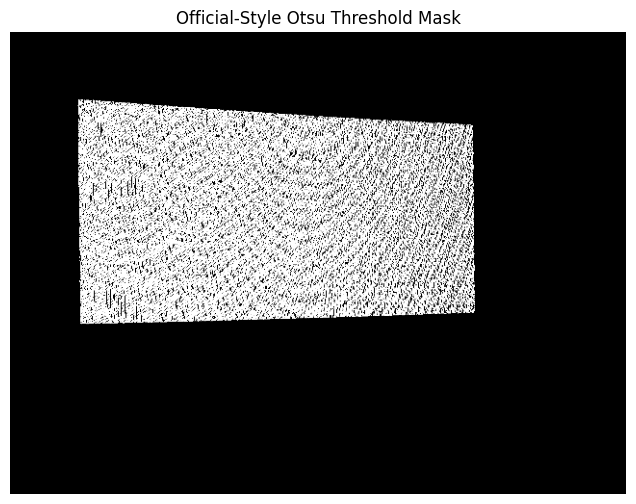

In [ ]:
_, thresholded_disp = cv2.threshold(
    scaledDisparityMap,
    0,
    255,
    cv2.THRESH_OTSU + cv2.THRESH_BINARY
)

dst = cv2.resize(
    thresholded_disp,
    (640, 480),
    interpolation=cv2.INTER_LINEAR_EXACT
)

plt.figure(figsize=(8, 6))
plt.imshow(dst, cmap="gray")
plt.title("Official-Style Otsu Threshold Mask")
plt.axis("off")
plt.show()

In [ ]:
disparity_32f = disparityMap.astype(np.float32)

pointcloud = cv2.reprojectImageTo3D(
    disparity_32f,
    Q,
    handleMissingValues=True,
    ddepth=-1
)

print("Point cloud shape:", pointcloud.shape)

Point cloud shape: (1280, 1920, 3)


In [ ]:
X = pointcloud[:, :, 0]
Y = pointcloud[:, :, 1]
Z = pointcloud[:, :, 2]

mask = thresholded_disp > 0
mask &= np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)

# remove extreme values only for Colab visualization stability
z_vals = Z[mask]
if z_vals.size > 0:
    z_lo, z_hi = np.percentile(z_vals, [2, 98])
    mask &= (Z >= z_lo) & (Z <= z_hi)

print("Valid points:", np.sum(mask))

# Use one rectified pattern as grayscale color
color = cv2.cvtColor(captured_pattern[0][0], cv2.COLOR_GRAY2RGB)

step = 4

X_s = X[::step, ::step]
Y_s = Y[::step, ::step]
Z_s = Z[::step, ::step]
M_s = mask[::step, ::step]
C_s = color[::step, ::step]

px = X_s[M_s].flatten()
py = Y_s[M_s].flatten()
pz = Z_s[M_s].flatten()
pc = C_s[M_s].reshape(-1, 3)

color_strings = [
    f"rgb({int(r)}, {int(g)}, {int(b)})"
    for r, g, b in pc
]

fig = go.Figure(data=[
    go.Scatter3d(
        x=px,
        y=-py,
        z=pz,
        mode="markers",
        marker=dict(
            size=2,
            color=color_strings,
            opacity=0.8
        )
    )
])

fig.update_layout(
    title="Point Cloud from Official OpenCV Pipeline",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    width=850,
    height=650
)

fig.show()

Valid points: 552146


# Volumetric Stereo

---

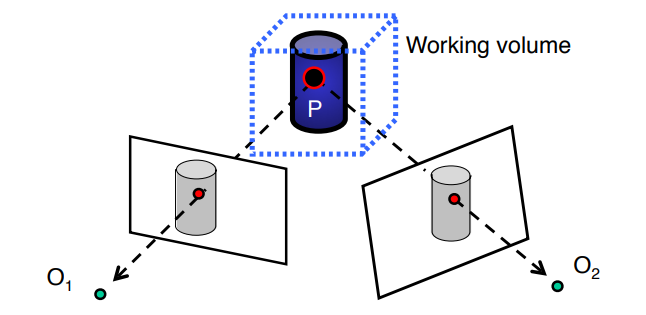

## Core Idea

Instead of reconstructing 3D points directly from image matches, **volumetric stereo** first divides 3D space into many small voxels.

Then it checks whether each voxel is consistent with multiple camera images.

$$
\text{3D volume}
\rightarrow
\text{voxels}
\rightarrow
\text{project to images}
\rightarrow
\text{consistency test}
\rightarrow
\text{3D shape}
$$

# Voxel

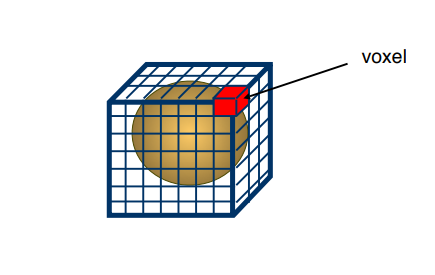

Divide the 3D space into small cubes called **voxels**.

$$
V = \{\mathbf{X}_j\}_{j=1}^{N^3}
$$

Each voxel has an occupancy label:

$$
O_j =
\begin{cases}
1, & \text{occupied} \\
0, & \text{empty}
\end{cases}
$$

The goal is to find the set of occupied voxels:

$$
\hat{S} = \{\mathbf{X}_j \in V \mid O_j = 1\}
$$

where $\hat{S}$ is the reconstructed 3D shape.

# Volumetric stereo
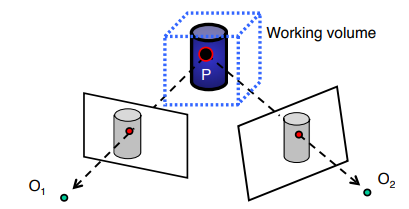
1. Hypothesis: pick up a point within the volume
2. Project this point into 2 (or more) images
3. Validation: are the observations consistent?

# Consistency? How do we decide if a voxel is valid?

Silhouette/Contour consistency → Space Carving

Color consistency → Voxel Coloring

# Method 1: Space Carving

---

## Basic Idea

Space carving uses object silhouettes to remove empty voxels.

If a voxel projects outside the object silhouette in any camera view, it cannot belong to the object.

---

## Projection

For camera \(i\):

$$
\mathbf{x}_i = \pi(\mathbf{P}_i \mathbf{X})
$$

where:

- $\mathbf{X}$: voxel center
- $\mathbf{P}_i$: camera projection matrix
- $\pi(\cdot)$: perspective projection
- $\mathbf{x}_i$: projected image point

# Visual hull in 2D
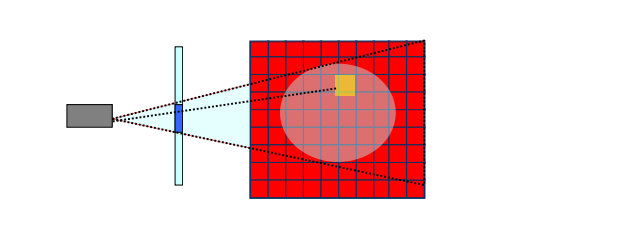

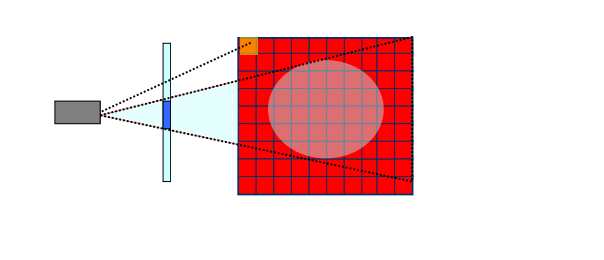

# Visual hull in 2D
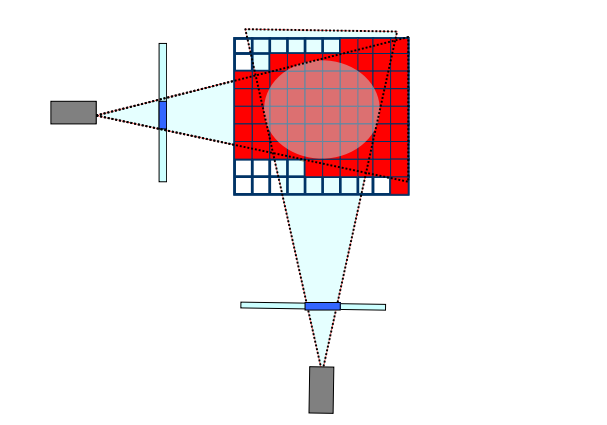

# Visual hull in 2D
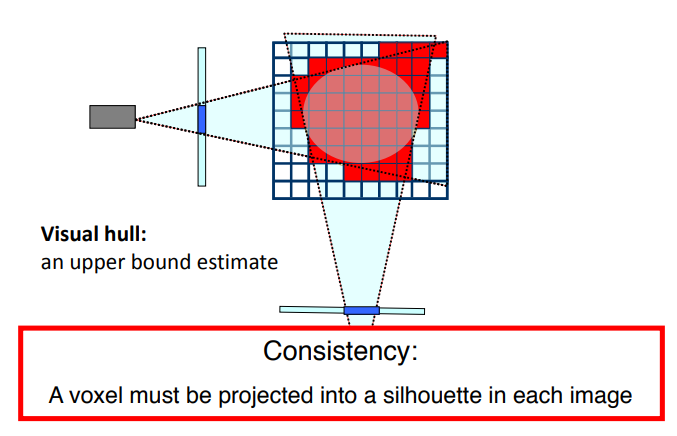

# Visual Hull

---

Each silhouette defines a **visual cone**.

The real object must lie inside every visual cone.

The visual hull is the intersection of all visual cones:

$$
\hat{V}_{visual}
=
\bigcap_{i=1}^{M}
\operatorname{Cone}(S_i, C_i)
$$

where:

- $S_i$: silhouette in camera $i$  
- $C_i$: camera center  
- $M$: number of cameras  



# Space Carving Consistency

---

Let the silhouette mask in camera $i$ be:

$$
S_i(x,y) \in \{0,1\}
$$

where:

- $S_i(x,y)=1$: inside object silhouette  
- $S_i(x,y)=0$: outside object silhouette  

A voxel is kept only if it projects inside all silhouettes:

$$
\mathbf{X} \in \hat{V}
\Longleftrightarrow
S_i(\pi(\mathbf{P}_i\mathbf{X})) = 1,\quad \forall i
$$

If one camera sees it outside the silhouette:

$$
\exists i,\ S_i(\pi(\mathbf{P}_i\mathbf{X})) = 0
\Rightarrow
\mathbf{X}\ \text{is empty}
$$

In [ ]:
!wget -q https://vision.middlebury.edu/mview/data/data/dinoSparseRing.zip -O /content/dinoSparseRing.zip
!unzip -q -o /content/dinoSparseRing.zip -d /content/

!find /content -maxdepth 3 -type f | head -30

/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/default_configs.db
/content/.config/gce
/content/.config/.last_update_check.json
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/configurations/config_default
/content/dinoSparseRing/dinoSR0011.png
/content/dinoSparseRing/dinoSR0001.png
/content/dinoSparseRing/README.txt
/content/dinoSparseRing/dinoSR0004.png
/content/dinoSparseRing/dinoSR0014.png
/content/dinoSparseRing/dinoSR0002.png
/content/dinoSparseRing/dinoSR_par.txt
/content/dinoSparseRing/dinoSR0003.png
/content/dinoSparseRing/dinoSR0010.png
/content/dinoSparseRing/dinoSR0009.png
/content/dinoSparseRing/dinoSR0005.png
/content/dinoSparseRing/dinoSR0008.png
/content/dinoSparseRing/dinoSR_ang.txt
/content/dinoSparseRing/dinoSR0007.png
/content/dinoSparseRing/dinoSR0015.png
/content/dinoSparseRing/dinoSR_good_silhouette

In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import ndimage

In [ ]:
# Find folder containing dinoSR_par.txt
candidates = glob.glob("/content/**/dinoSR_par.txt", recursive=True)

if len(candidates) == 0:
    raise RuntimeError("Cannot find dinoSR_par.txt. Dataset may not be downloaded correctly.")

PAR_PATH = candidates[0]
DATA_DIR = os.path.dirname(PAR_PATH)

GOOD_LIST_PATH = os.path.join(DATA_DIR, "dinoSR_good_silhouette_images.txt")
README_PATH = os.path.join(DATA_DIR, "README.txt")

print("DATA_DIR:", DATA_DIR)
print("PAR_PATH:", PAR_PATH)
print("GOOD_LIST_PATH:", GOOD_LIST_PATH)
print("README_PATH:", README_PATH)

print("Files:")
print(os.listdir(DATA_DIR)[:20])

DATA_DIR: /content/dinoSparseRing
PAR_PATH: /content/dinoSparseRing/dinoSR_par.txt
GOOD_LIST_PATH: /content/dinoSparseRing/dinoSR_good_silhouette_images.txt
README_PATH: /content/dinoSparseRing/README.txt
Files:
['dinoSR0011.png', 'dinoSR0001.png', 'README.txt', 'dinoSR0004.png', 'dinoSR0014.png', 'dinoSR0002.png', 'dinoSR_par.txt', 'dinoSR0003.png', 'dinoSR0010.png', 'dinoSR0009.png', 'dinoSR0005.png', 'dinoSR0008.png', 'dinoSR_ang.txt', 'dinoSR0007.png', 'dinoSR0015.png', 'dinoSR_good_silhouette_images.txt', 'dinoSR0012.png', 'dinoSR0006.png', 'dinoSR0016.png', 'dinoSR0013.png']


In [ ]:
def read_camera_params(par_path):
    cameras = {}

    with open(par_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    n = int(lines[0])

    for line in lines[1:]:
        parts = line.split()
        name = parts[0]
        nums = np.array([float(x) for x in parts[1:]], dtype=np.float64)

        K = nums[0:9].reshape(3, 3)
        R = nums[9:18].reshape(3, 3)
        t = nums[18:21].reshape(3, 1)

        P = K @ np.hstack([R, t])

        cameras[name] = {
            "K": K,
            "R": R,
            "t": t,
            "P": P
        }

    print("Number of cameras:", len(cameras))
    return cameras

cameras = read_camera_params(PAR_PATH)

first_name = list(cameras.keys())[0]
print("Example image:", first_name)
print("Projection matrix P:\n", cameras[first_name]["P"])

Number of cameras: 16
Example image: dinoSR0001.png
Projection matrix P:
 [[-6.04322416e+02  3.13397314e+03  9.33850029e+02  1.78710771e+02]
 [-3.08602553e+03 -2.05839788e+02 -1.23824718e+03  3.71273243e+01]
 [-4.03315365e-01 -2.39841306e-01  8.83069362e-01  6.73097816e-01]]


In [ ]:
with open(GOOD_LIST_PATH, "r") as f:
    good_names = [line.strip() for line in f.readlines() if line.strip()]

print("Number of good silhouette views:", len(good_names))
print(good_names)

Number of good silhouette views: 15
['dinoSR0001.png', 'dinoSR0002.png', 'dinoSR0003.png', 'dinoSR0004.png', 'dinoSR0005.png', 'dinoSR0007.png', 'dinoSR0008.png', 'dinoSR0009.png', 'dinoSR0010.png', 'dinoSR0011.png', 'dinoSR0012.png', 'dinoSR0013.png', 'dinoSR0014.png', 'dinoSR0015.png', 'dinoSR0016.png']


Image size: 640 480


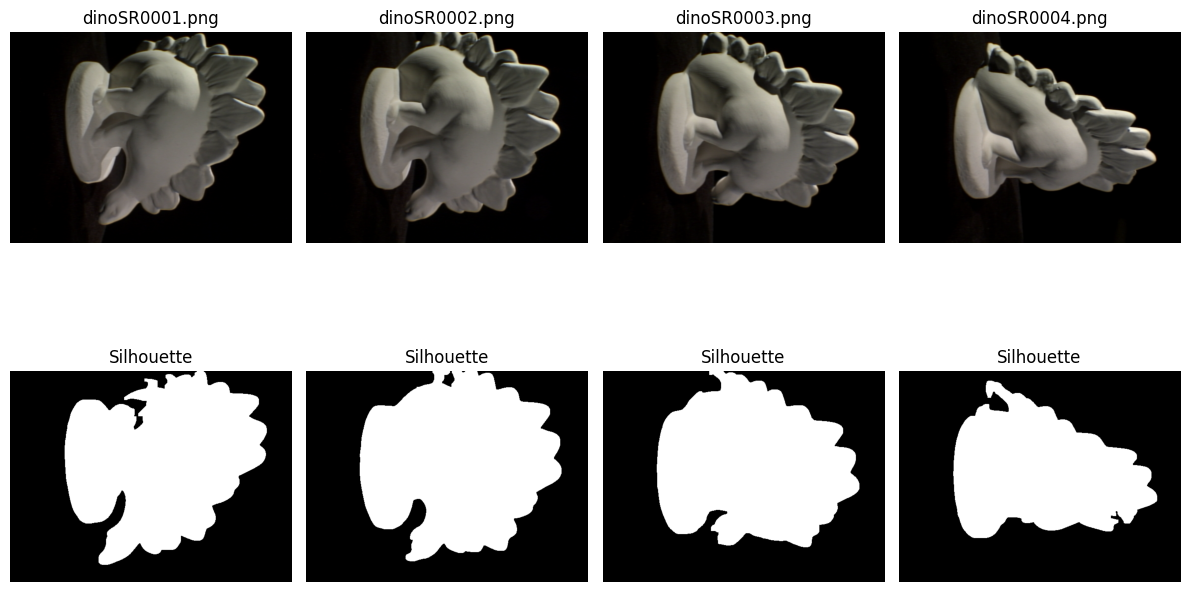

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def extract_silhouette(img_bgr):
    """
    Extract object silhouette for visual hull / space carving.

    Output:
        mask: boolean array, True = object, False = background
    """

    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Smooth image to reduce noise
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu automatic threshold
    _, mask = cv2.threshold(
        gray_blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Convert to 0 / 1
    mask = (mask > 0).astype(np.uint8)

    # If foreground area is too large, Otsu likely selected background
    if mask.mean() > 0.5:
        mask = 1 - mask

    kernel = np.ones((3, 3), np.uint8)

    # Remove small noise
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Fill small gaps inside object boundary
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    # Keep largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest_label).astype(np.uint8)

    # Fill holes inside silhouette
    mask = ndimage.binary_fill_holes(mask).astype(np.uint8)

    # Slightly enlarge silhouette.
    # For visual hull, slightly larger masks are safer than too-small masks.
    mask = cv2.dilate(mask, kernel, iterations=2)

    return mask.astype(bool)


images = {}
masks = {}

for name in good_names:
    path = os.path.join(DATA_DIR, name)
    img = cv2.imread(path)

    if img is None:
        raise RuntimeError(f"Failed to read image: {path}")

    mask = extract_silhouette(img)

    images[name] = img
    masks[name] = mask

H, W = list(masks.values())[0].shape
print("Image size:", W, H)

# Show examples
plt.figure(figsize=(12, 8))

for i, name in enumerate(good_names[:4]):
    img_rgb = cv2.cvtColor(images[name], cv2.COLOR_BGR2RGB)
    mask = masks[name]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(name)
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(mask, cmap="gray")
    plt.title("Silhouette")
    plt.axis("off")

plt.tight_layout()
plt.show()

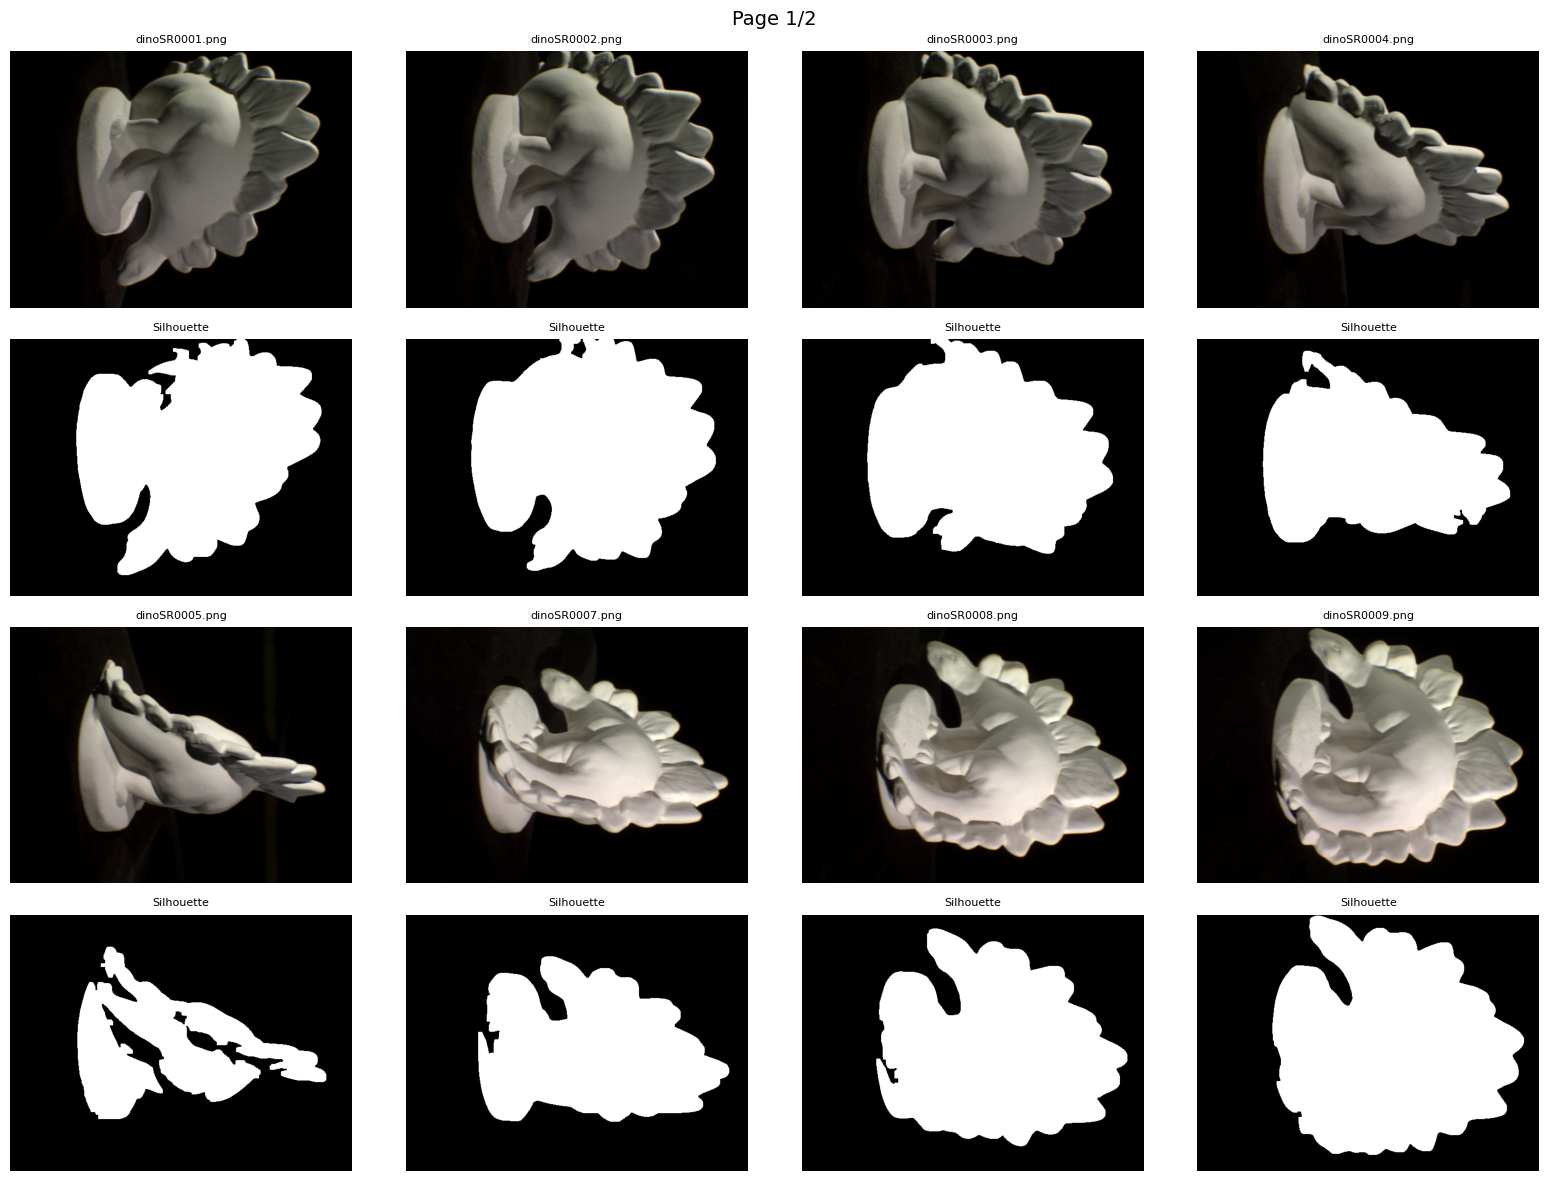

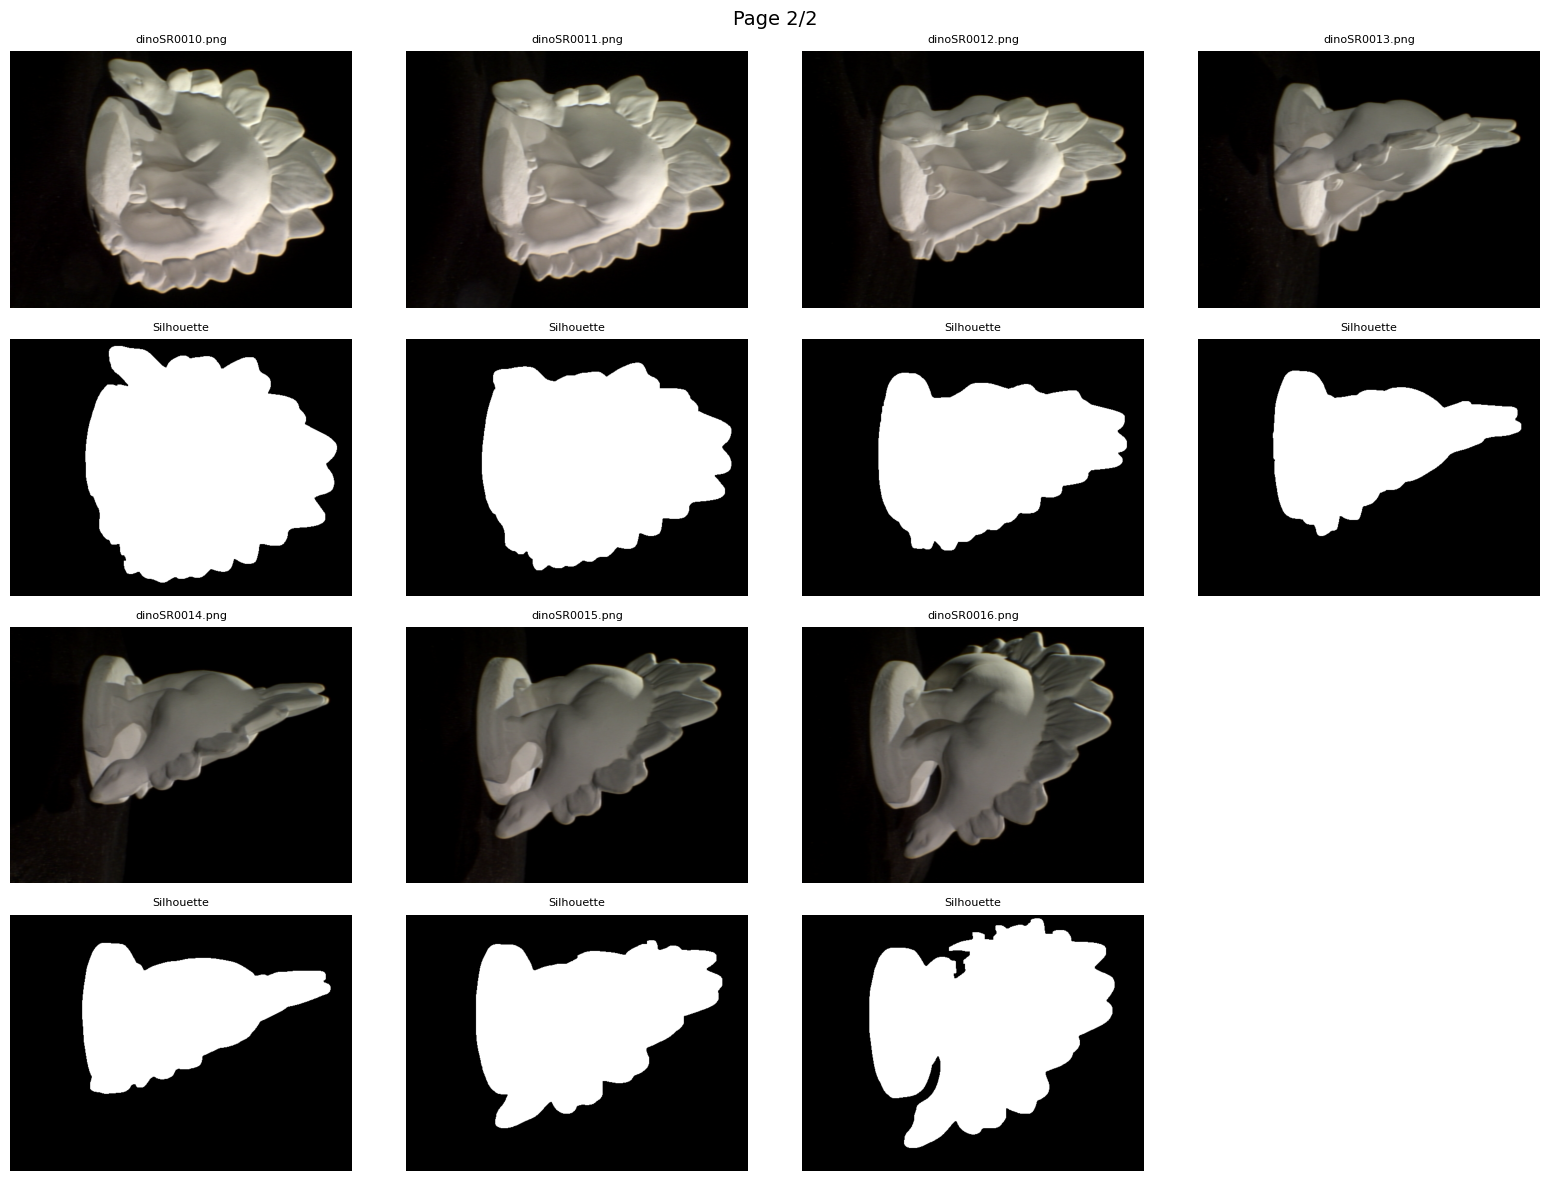

In [ ]:
# # Show all images and silhouettes in pages
# import math

# per_page = 8
# cols = 4
# num_views = len(good_names)
# num_pages = math.ceil(num_views / per_page)

# for page in range(num_pages):
#     start = page * per_page
#     end = min(start + per_page, num_views)
#     names_page = good_names[start:end]

#     view_rows = math.ceil(len(names_page) / cols)

#     plt.figure(figsize=(4 * cols, 6 * view_rows))
#     plt.suptitle(f"Page {page + 1}/{num_pages}", fontsize=14)

#     for i, name in enumerate(names_page):
#         img_rgb = cv2.cvtColor(images[name], cv2.COLOR_BGR2RGB)
#         mask = masks[name]

#         block_row = i // cols
#         col = i % cols

#         img_pos = block_row * 2 * cols + col + 1
#         mask_pos = img_pos + cols

#         plt.subplot(view_rows * 2, cols, img_pos)
#         plt.imshow(img_rgb)
#         plt.title(name, fontsize=8)
#         plt.axis("off")

#         plt.subplot(view_rows * 2, cols, mask_pos)
#         plt.imshow(mask, cmap="gray")
#         plt.title("Silhouette", fontsize=8)
#         plt.axis("off")

#     plt.tight_layout()
#     plt.show()

In [ ]:
bbox_min = np.array([-0.061897, -0.018874, -0.057845], dtype=np.float32)
bbox_max = np.array([ 0.010897,  0.068227,  0.015495], dtype=np.float32)

padding = 0.008
bbox_min = bbox_min - padding
bbox_max = bbox_max + padding

# Increase grid_N for better quality, decrease for faster runtime
grid_N = 72

xs = np.linspace(bbox_min[0], bbox_max[0], grid_N)
ys = np.linspace(bbox_min[1], bbox_max[1], grid_N)
zs = np.linspace(bbox_min[2], bbox_max[2], grid_N)

X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")

voxels = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
num_voxels = voxels.shape[0]

print("Voxel grid resolution:", grid_N, "x", grid_N, "x", grid_N)
print("Total voxels:", num_voxels)
print("Bounding box min:", bbox_min)
print("Bounding box max:", bbox_max)

Voxel grid resolution: 72 x 72 x 72
Total voxels: 373248
Bounding box min: [-0.069897 -0.026874 -0.065845]
Bounding box max: [0.018897 0.076227 0.023495]


In [ ]:
def project_points(P, points_3d):
    """
    P: 3 x 4 projection matrix
    points_3d: N x 3
    return: u, v, valid_depth
    """
    N = points_3d.shape[0]
    homog = np.hstack([points_3d, np.ones((N, 1), dtype=np.float32)])
    proj = homog @ P.T

    z = proj[:, 2]
    valid_depth = z > 1e-8

    u = proj[:, 0] / z
    v = proj[:, 1] / z

    return u, v, valid_depth

In [ ]:
# occupied = np.ones(num_voxels, dtype=bool)

# for view_idx, name in enumerate(good_names):
#     P = cameras[name]["P"]
#     mask = masks[name]

#     u, v, valid_depth = project_points(P, voxels)

#     ui = np.round(u).astype(np.int32)
#     vi = np.round(v).astype(np.int32)

#     inside_image = (
#         valid_depth &
#         (ui >= 0) & (ui < W) &
#         (vi >= 0) & (vi < H)
#     )

#     inside_silhouette = np.zeros(num_voxels, dtype=bool)

#     valid_idx = np.where(inside_image)[0]
#     inside_silhouette[valid_idx] = mask[vi[valid_idx], ui[valid_idx]]

#     occupied &= inside_silhouette

#     print(
#         f"View {view_idx+1:02d}/{len(good_names)} {name}: "
#         f"remaining voxels = {occupied.sum()}"
#     )

# occupied_voxels = voxels[occupied]

# print("Final occupied voxels:", occupied_voxels.shape[0])

View 01/15 dinoSR0001.png: remaining voxels = 213564
View 02/15 dinoSR0002.png: remaining voxels = 194303
View 03/15 dinoSR0003.png: remaining voxels = 165025
View 04/15 dinoSR0004.png: remaining voxels = 112674
View 05/15 dinoSR0005.png: remaining voxels = 58366
View 06/15 dinoSR0007.png: remaining voxels = 48180
View 07/15 dinoSR0008.png: remaining voxels = 47015
View 08/15 dinoSR0009.png: remaining voxels = 46497
View 09/15 dinoSR0010.png: remaining voxels = 46249
View 10/15 dinoSR0011.png: remaining voxels = 46006
View 11/15 dinoSR0012.png: remaining voxels = 45666
View 12/15 dinoSR0013.png: remaining voxels = 44894
View 13/15 dinoSR0014.png: remaining voxels = 41876
View 14/15 dinoSR0015.png: remaining voxels = 41438
View 15/15 dinoSR0016.png: remaining voxels = 41212
Final occupied voxels: 41212


In [ ]:
occupied = np.ones(num_voxels, dtype=bool)

remaining_counts = []
snapshots = {}

snapshot_views = [1, 3, 6, 10, len(good_names)]

for view_idx, name in enumerate(good_names):
    P = cameras[name]["P"]
    mask = masks[name]

    u, v, valid_depth = project_points(P, voxels)

    ui = np.round(u).astype(np.int32)
    vi = np.round(v).astype(np.int32)

    inside_image = (
        valid_depth &
        (ui >= 0) & (ui < W) &
        (vi >= 0) & (vi < H)
    )

    inside_silhouette = np.zeros(num_voxels, dtype=bool)

    valid_idx = np.where(inside_image)[0]
    inside_silhouette[valid_idx] = mask[vi[valid_idx], ui[valid_idx]]

    occupied &= inside_silhouette

    remaining_counts.append(occupied.sum())

    if view_idx + 1 in snapshot_views:
        snapshots[view_idx + 1] = voxels[occupied].copy()

    print(
        f"After view {view_idx+1:02d}/{len(good_names)} {name}: "
        f"remaining voxels = {occupied.sum()}"
    )

occupied_voxels = voxels[occupied]

print("Final occupied voxels:", occupied_voxels.shape[0])

After view 01/15 dinoSR0001.png: remaining voxels = 213564
After view 02/15 dinoSR0002.png: remaining voxels = 194303
After view 03/15 dinoSR0003.png: remaining voxels = 165025
After view 04/15 dinoSR0004.png: remaining voxels = 112674
After view 05/15 dinoSR0005.png: remaining voxels = 58366
After view 06/15 dinoSR0007.png: remaining voxels = 48180
After view 07/15 dinoSR0008.png: remaining voxels = 47015
After view 08/15 dinoSR0009.png: remaining voxels = 46497
After view 09/15 dinoSR0010.png: remaining voxels = 46249
After view 10/15 dinoSR0011.png: remaining voxels = 46006
After view 11/15 dinoSR0012.png: remaining voxels = 45666
After view 12/15 dinoSR0013.png: remaining voxels = 44894
After view 13/15 dinoSR0014.png: remaining voxels = 41876
After view 14/15 dinoSR0015.png: remaining voxels = 41438
After view 15/15 dinoSR0016.png: remaining voxels = 41212
Final occupied voxels: 41212


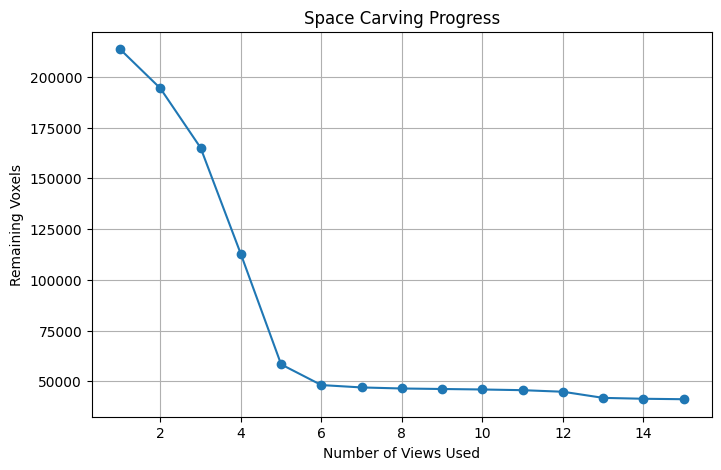

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(remaining_counts) + 1), remaining_counts, marker="o")
plt.xlabel("Number of Views Used")
plt.ylabel("Remaining Voxels")
plt.title("Space Carving Progress")
plt.grid(True)
plt.show()

In [ ]:
fig = go.Figure()

for k, pts in snapshots.items():
    if pts.shape[0] == 0:
        continue

    # Downsample each snapshot
    step = max(1, pts.shape[0] // 4000)
    pts_s = pts[::step]

    fig.add_trace(go.Scatter3d(
        x=pts_s[:, 0],
        y=pts_s[:, 1],
        z=pts_s[:, 2],
        mode="markers",
        marker=dict(
            size=2,
            color=pts_s[:, 2],
            colorscale="Viridis",
            opacity=0.8
        ),
        name=f"After {k} views",
        visible=False
    ))

# Make final snapshot visible by default
fig.data[-1].visible = True

buttons = []
for i, trace in enumerate(fig.data):
    visible = [False] * len(fig.data)
    visible[i] = True
    buttons.append(dict(
        label=trace.name,
        method="update",
        args=[{"visible": visible},
              {"title": f"Space Carving Result: {trace.name}"}]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=len(fig.data)-1,
        buttons=buttons,
        x=0.05,
        y=1.05
    )],
    title="Space Carving Progression",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=850,
    height=650
)

fig.show()

# Advantages of Space carving

Robust	and	simple

No need to solve for	correspondences

# Limitation of space carving

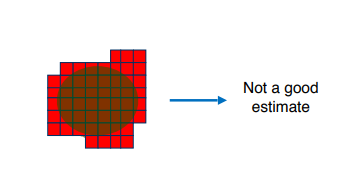


# Limitation of space carving
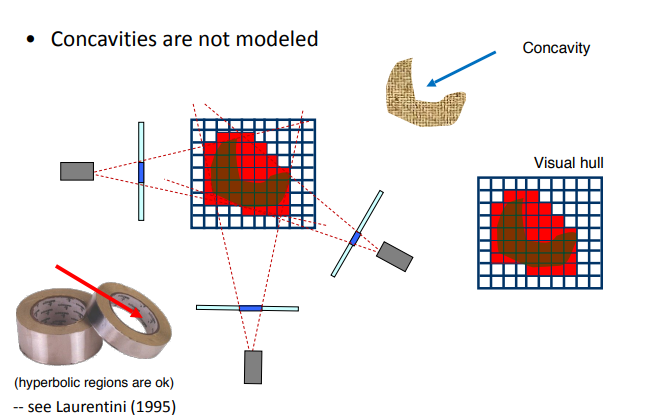

# Method 2: Voxel Coloring

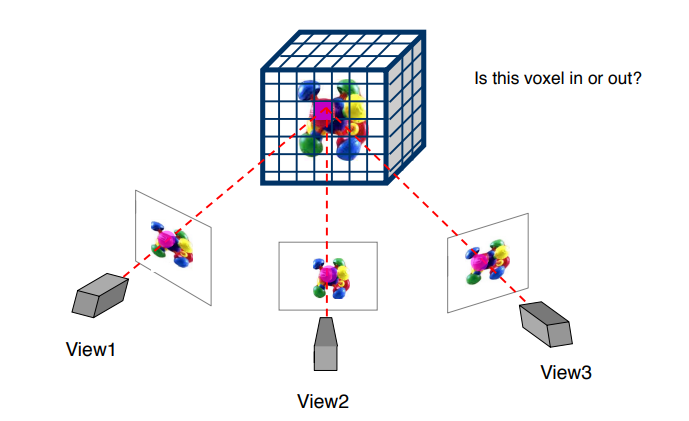

---

## Basic Idea

Space carving only uses silhouettes.

Voxel coloring uses **color consistency** across multiple views.

If a voxel belongs to the real surface, its projections in different images should have similar colors.

---

For voxel $\mathbf{X}$, project it into camera $i$:

$$
\mathbf{x}_i = \pi(\mathbf{P}_i\mathbf{X})
$$

Read the color:

$$
\mathbf{c}_i(\mathbf{X}) = I_i(\mathbf{x}_i)
$$


# Photo-Consistency

---

For a voxel $\mathbf{X}$, compute the average observed color:

$$
\bar{\mathbf{c}}(\mathbf{X})
=
\frac{1}{|\mathcal{V}(\mathbf{X})|}
\sum_{i \in \mathcal{V}(\mathbf{X})}
\mathbf{c}_i(\mathbf{X})
$$

where $\mathcal{V}(\mathbf{X})$ is the set of cameras that can see voxel $\mathbf{X}$.

The photo-consistency cost is:

$$
E_{photo}(\mathbf{X})
=
\frac{1}{|\mathcal{V}(\mathbf{X})|}
\sum_{i \in \mathcal{V}(\mathbf{X})}
\left\|
\mathbf{c}_i(\mathbf{X})-\bar{\mathbf{c}}(\mathbf{X})
\right\|^2
$$

Decision rule:

$$
E_{photo}(\mathbf{X}) < \tau
\Rightarrow
\mathbf{X}\ \text{is photo-consistent}
$$

# Visibility Problem

---

Not every voxel is visible in every camera.

A voxel may be occluded by the object itself.

Therefore, photo-consistency should only use visible views:

$$
\mathcal{V}(\mathbf{X})
=
\{i \mid \mathbf{X}\ \text{is visible in camera}\ i\}
$$

Then:

$$
E_{photo}(\mathbf{X})
=
\frac{1}{|\mathcal{V}(\mathbf{X})|}
\sum_{i \in \mathcal{V}(\mathbf{X})}
\left\|
\mathbf{c}_i(\mathbf{X})-\bar{\mathbf{c}}(\mathbf{X})
\right\|^2
$$

---

## Key Difficulty

Incorrect visibility reasoning can cause wrong carving or wrong surface reconstruction.

In [ ]:
import os
import re
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
candidates = glob.glob("/content/**/dinoSR_par.txt", recursive=True)

if len(candidates) == 0:
    raise RuntimeError("Cannot find dinoSR_par.txt.")

PAR_PATH = candidates[0]
DATA_DIR = os.path.dirname(PAR_PATH)

GOOD_LIST_PATH = os.path.join(DATA_DIR, "dinoSR_good_silhouette_images.txt")

print("DATA_DIR:", DATA_DIR)
print("PAR_PATH:", PAR_PATH)
print("GOOD_LIST_PATH:", GOOD_LIST_PATH)
print(os.listdir(DATA_DIR)[:20])

DATA_DIR: /content/dinoSparseRing
PAR_PATH: /content/dinoSparseRing/dinoSR_par.txt
GOOD_LIST_PATH: /content/dinoSparseRing/dinoSR_good_silhouette_images.txt
['dinoSR0011.png', 'dinoSR0001.png', 'README.txt', 'dinoSR0004.png', 'dinoSR0014.png', 'dinoSR0002.png', 'dinoSR_par.txt', 'dinoSR0003.png', 'dinoSR0010.png', 'dinoSR0009.png', 'dinoSR0005.png', 'dinoSR0008.png', 'dinoSR_ang.txt', 'dinoSR0007.png', 'dinoSR0015.png', 'dinoSR_good_silhouette_images.txt', 'dinoSR0012.png', 'dinoSR0006.png', 'dinoSR0016.png', 'dinoSR0013.png']


In [ ]:
def read_camera_params(par_path):
    cameras = {}

    with open(par_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    n = int(lines[0])

    for line in lines[1:]:
        parts = line.split()
        name = parts[0]
        nums = np.array([float(x) for x in parts[1:]], dtype=np.float64)

        K = nums[0:9].reshape(3, 3)
        R = nums[9:18].reshape(3, 3)
        t = nums[18:21].reshape(3, 1)

        P = K @ np.hstack([R, t])

        cameras[name] = {
            "K": K,
            "R": R,
            "t": t,
            "P": P
        }

    print("Number of cameras:", len(cameras))
    return cameras

cameras = read_camera_params(PAR_PATH)

first_name = list(cameras.keys())[0]
print("Example image:", first_name)
print("P matrix:\n", cameras[first_name]["P"])

Number of cameras: 16
Example image: dinoSR0001.png
P matrix:
 [[-6.04322416e+02  3.13397314e+03  9.33850029e+02  1.78710771e+02]
 [-3.08602553e+03 -2.05839788e+02 -1.23824718e+03  3.71273243e+01]
 [-4.03315365e-01 -2.39841306e-01  8.83069362e-01  6.73097816e-01]]


In [ ]:
with open(GOOD_LIST_PATH, "r") as f:
    good_names = [line.strip() for line in f.readlines() if line.strip()]

print("Good views:", len(good_names))
print(good_names)

Good views: 15
['dinoSR0001.png', 'dinoSR0002.png', 'dinoSR0003.png', 'dinoSR0004.png', 'dinoSR0005.png', 'dinoSR0007.png', 'dinoSR0008.png', 'dinoSR0009.png', 'dinoSR0010.png', 'dinoSR0011.png', 'dinoSR0012.png', 'dinoSR0013.png', 'dinoSR0014.png', 'dinoSR0015.png', 'dinoSR0016.png']


Image size: 640 480
Number of views: 15


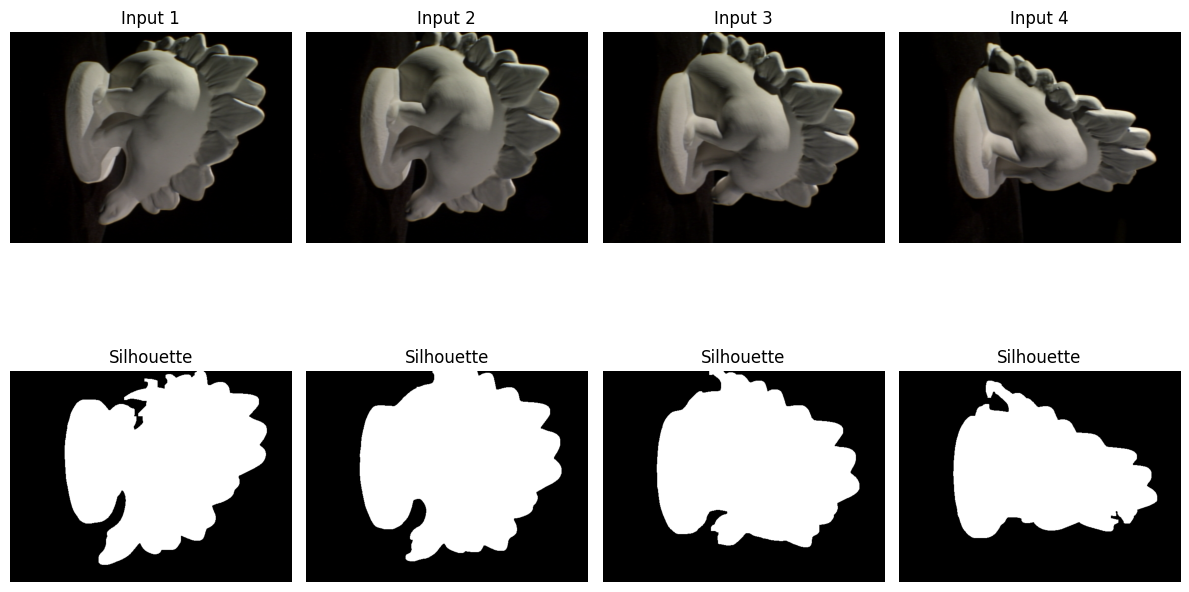

In [ ]:
def fill_holes_opencv(mask):
    """
    Fill holes inside a binary mask using OpenCV flood fill.
    Input mask: uint8, values 0 or 1
    Output mask: uint8, values 0 or 1
    """
    mask_uint8 = (mask * 255).astype(np.uint8)

    h, w = mask_uint8.shape
    flood = mask_uint8.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)

    cv2.floodFill(flood, flood_mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    filled = cv2.bitwise_or(mask_uint8, flood_inv)

    return (filled > 0).astype(np.uint8)


def extract_silhouette(img_bgr):
    """
    Extract silhouette mask for voxel coloring / space carving.

    Output:
        mask_bool: True = object, False = background
    """

    # Convert BGR to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Smooth image to reduce noise
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu automatic threshold
    _, mask = cv2.threshold(
        gray_blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Convert to 0 / 1
    mask = (mask > 0).astype(np.uint8)

    # If the white area is too large, Otsu probably selected the background
    if mask.mean() > 0.5:
        mask = 1 - mask

    kernel = np.ones((3, 3), np.uint8)

    # Remove small isolated noise
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # Fill small gaps in the object region
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=3
    )

    # Keep only the largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest_label).astype(np.uint8)

    # Fill holes inside the silhouette
    mask = fill_holes_opencv(mask)

    # Slightly enlarge the silhouette.
    # For visual hull / space carving, slightly larger is safer than too small.
    mask = cv2.dilate(mask, kernel, iterations=2)

    return mask.astype(bool)


images_rgb = {}
images_float = {}
masks = {}

for name in good_names:
    path = os.path.join(DATA_DIR, name)
    img_bgr = cv2.imread(path)

    if img_bgr is None:
        raise RuntimeError(f"Failed to read image: {path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask = extract_silhouette(img_bgr)

    images_rgb[name] = img_rgb
    images_float[name] = img_rgb.astype(np.float32) / 255.0
    masks[name] = mask

H, W = list(masks.values())[0].shape

print("Image size:", W, H)
print("Number of views:", len(good_names))

plt.figure(figsize=(12, 8))

for i, name in enumerate(good_names[:4]):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images_rgb[name])
    plt.title(f"Input {i+1}")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(masks[name], cmap="gray")
    plt.title("Silhouette")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
bbox_min = np.array([-0.061897, -0.018874, -0.057845], dtype=np.float32)
bbox_max = np.array([ 0.010897,  0.068227,  0.015495], dtype=np.float32)

padding = 0.008
bbox_min = bbox_min - padding
bbox_max = bbox_max + padding

grid_N = 60

xs = np.linspace(bbox_min[0], bbox_max[0], grid_N)
ys = np.linspace(bbox_min[1], bbox_max[1], grid_N)
zs = np.linspace(bbox_min[2], bbox_max[2], grid_N)

X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")

voxels = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
num_voxels = voxels.shape[0]

print("Voxel grid:", grid_N, "x", grid_N, "x", grid_N)
print("Total voxels:", num_voxels)

Voxel grid: 60 x 60 x 60
Total voxels: 216000


In [ ]:
def project_points(P, points_3d):
    N = points_3d.shape[0]

    homog = np.hstack([
        points_3d,
        np.ones((N, 1), dtype=np.float32)
    ])

    proj = homog @ P.T

    z = proj[:, 2]
    valid_depth = z > 1e-8

    u = proj[:, 0] / z
    v = proj[:, 1] / z

    return u, v, valid_depth

In [ ]:
occupied = np.ones(num_voxels, dtype=bool)

for view_idx, name in enumerate(good_names):
    P = cameras[name]["P"]
    mask = masks[name]

    u, v, valid_depth = project_points(P, voxels)

    ui = np.round(u).astype(np.int32)
    vi = np.round(v).astype(np.int32)

    inside_image = (
        valid_depth &
        (ui >= 0) & (ui < W) &
        (vi >= 0) & (vi < H)
    )

    inside_silhouette = np.zeros(num_voxels, dtype=bool)

    valid_idx = np.where(inside_image)[0]
    inside_silhouette[valid_idx] = mask[vi[valid_idx], ui[valid_idx]]

    occupied &= inside_silhouette

    print(
        f"View {view_idx+1:02d}/{len(good_names)} {name}: "
        f"remaining voxels = {occupied.sum()}"
    )

visual_hull_voxels = voxels[occupied]

print("Visual hull voxels:", visual_hull_voxels.shape[0])

View 01/15 dinoSR0001.png: remaining voxels = 123064
View 02/15 dinoSR0002.png: remaining voxels = 112106
View 03/15 dinoSR0003.png: remaining voxels = 95002
View 04/15 dinoSR0004.png: remaining voxels = 64763
View 05/15 dinoSR0005.png: remaining voxels = 33591
View 06/15 dinoSR0007.png: remaining voxels = 27731
View 07/15 dinoSR0008.png: remaining voxels = 27071
View 08/15 dinoSR0009.png: remaining voxels = 26763
View 09/15 dinoSR0010.png: remaining voxels = 26631
View 10/15 dinoSR0011.png: remaining voxels = 26478
View 11/15 dinoSR0012.png: remaining voxels = 26284
View 12/15 dinoSR0013.png: remaining voxels = 25830
View 13/15 dinoSR0014.png: remaining voxels = 24082
View 14/15 dinoSR0015.png: remaining voxels = 23838
View 15/15 dinoSR0016.png: remaining voxels = 23707
Visual hull voxels: 23707


In [ ]:
def compute_voxel_color_consistency(
    voxels,
    candidate_mask,
    cameras,
    images_float,
    masks,
    view_names,
    chunk_size=20000,
    min_views=3
):
    candidate_indices = np.where(candidate_mask)[0]

    scores_global = np.full(voxels.shape[0], np.nan, dtype=np.float32)
    colors_global = np.zeros((voxels.shape[0], 3), dtype=np.float32)
    counts_global = np.zeros(voxels.shape[0], dtype=np.int32)

    for start in range(0, len(candidate_indices), chunk_size):
        end = min(start + chunk_size, len(candidate_indices))
        idx = candidate_indices[start:end]

        pts = voxels[idx]
        n = pts.shape[0]

        feat_sum = np.zeros((n, 2), dtype=np.float32)
        feat_sq_sum = np.zeros((n, 2), dtype=np.float32)
        rgb_sum = np.zeros((n, 3), dtype=np.float32)
        count = np.zeros(n, dtype=np.int32)

        for name in view_names:
            P = cameras[name]["P"]
            img = images_float[name]
            mask = masks[name]

            u, v, valid_depth = project_points(P, pts)

            ui = np.round(u).astype(np.int32)
            vi = np.round(v).astype(np.int32)

            inside = (
                valid_depth &
                (ui >= 0) & (ui < W) &
                (vi >= 0) & (vi < H)
            )

            inside_idx = np.where(inside)[0]

            if inside_idx.size == 0:
                continue

            ui_valid = ui[inside_idx]
            vi_valid = vi[inside_idx]

            in_mask = mask[vi_valid, ui_valid]

            valid_local = inside_idx[in_mask]

            if valid_local.size == 0:
                continue

            rgb = img[vi[valid_local], ui[valid_local], :]

            # normalized RGB chromaticity: more robust to brightness changes
            denom = np.sum(rgb, axis=1, keepdims=True) + 1e-6
            chrom = rgb[:, :2] / denom

            feat_sum[valid_local] += chrom
            feat_sq_sum[valid_local] += chrom ** 2
            rgb_sum[valid_local] += rgb
            count[valid_local] += 1

        valid_count = count >= min_views

        if np.any(valid_count):
            mean_feat = feat_sum[valid_count] / count[valid_count, None]
            mean_sq_feat = feat_sq_sum[valid_count] / count[valid_count, None]
            var_feat = np.maximum(mean_sq_feat - mean_feat ** 2, 0)

            score = np.sqrt(np.mean(var_feat, axis=1))

            scores_global[idx[valid_count]] = score
            colors_global[idx[valid_count]] = rgb_sum[valid_count] / count[valid_count, None]
            counts_global[idx[valid_count]] = count[valid_count]

        print(f"Processed {end}/{len(candidate_indices)} candidate voxels")

    return scores_global, colors_global, counts_global

scores, voxel_colors, view_counts = compute_voxel_color_consistency(
    voxels=voxels,
    candidate_mask=occupied,
    cameras=cameras,
    images_float=images_float,
    masks=masks,
    view_names=good_names,
    chunk_size=20000,
    min_views=3
)

valid_scores = occupied & np.isfinite(scores) & (view_counts >= 3)

print("Voxels with valid color scores:", np.sum(valid_scores))
print("Score min/max:", np.nanmin(scores), np.nanmax(scores))

Processed 20000/23707 candidate voxels
Processed 23707/23707 candidate voxels
Voxels with valid color scores: 23707
Score min/max: 0.0019348615 0.15576099


Photo-consistency threshold: 0.007431799
Photo-consistent voxels: 16595


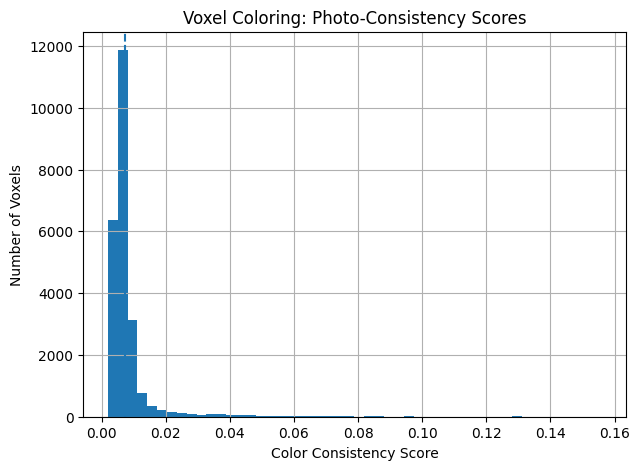

In [ ]:
keep_percentile = 70

threshold = np.nanpercentile(scores[valid_scores], keep_percentile)

photo_consistent = valid_scores & (scores <= threshold)

colored_voxels = voxels[photo_consistent]
colored_values = voxel_colors[photo_consistent]

print("Photo-consistency threshold:", threshold)
print("Photo-consistent voxels:", colored_voxels.shape[0])

plt.figure(figsize=(7, 5))
plt.hist(scores[valid_scores], bins=50)
plt.axvline(threshold, linestyle="--")
plt.xlabel("Color Consistency Score")
plt.ylabel("Number of Voxels")
plt.title("Voxel Coloring: Photo-Consistency Scores")
plt.grid(True)
plt.show()

In [ ]:
step = max(1, colored_voxels.shape[0] // 12000)

pts = colored_voxels[::step]
cols = colored_values[::step]

color_strings = [
    f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"
    for r, g, b in cols
]

fig = go.Figure(data=[
    go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(
            size=2,
            color=color_strings,
            opacity=0.85
        )
    )
])

fig.update_layout(
    title="Voxel Coloring Result",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
        bgcolor="white",
        xaxis=dict(backgroundcolor="white", gridcolor="lightgray"),
        yaxis=dict(backgroundcolor="white", gridcolor="lightgray"),
        zaxis=dict(backgroundcolor="white", gridcolor="lightgray")
    ),
    paper_bgcolor="white",
    width=850,
    height=650
)

fig.show()

# Recent Paper: Active Event-based Stereo Vision
https://openaccess.thecvf.com/content/CVPR2025/papers/Li_Active_Event-based_Stereo_Vision_CVPR_2025_paper.pdf


**CVPR 2025**

## Topic

Active stereo for high-speed depth sensing.

## Key Idea

Combine:

- binocular event cameras
- infrared structured-light projector
- lightweight stereo network

to estimate dense disparity / depth in low-light, low-texture, and high-speed scenes.

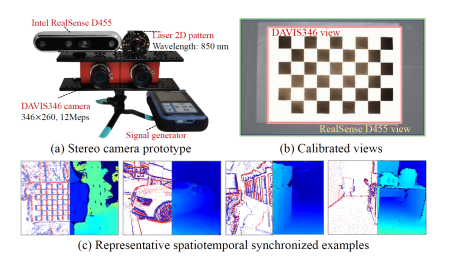

# 1. What Problem Does It Solve?

Traditional passive stereo relies on natural image texture.

It struggles in:

- low-texture regions
- low-light scenes
- fast motion
- weak correspondence signals

Event cameras are fast, but passive event stereo can still fail when the scene has few events.

## Main Problem

How can we obtain reliable stereo matching signals in fast, dark, or low-texture environments?

# 2. Method

## System Setup

The system uses:

- left event camera
- right event camera
- infrared structured-light projector

The projector adds artificial texture and triggers more useful events.

$$
\text{IR pattern}
\rightarrow
\text{stereo event streams}
\rightarrow
\text{ActiveEventNet}
\rightarrow
\text{dense disparity}
\rightarrow
\text{depth map}
$$

# 3. Mathematical Idea

The left and right event streams are generated from both natural light and projected light:

$$
S_l =
G(W_t^l[I(t)+P(t)] + N)
$$

$$
S_r =
G(W_t^r[I(t)+P(t)] + N)
$$

where:

- $I(t)$: natural scene intensity
- $P(t)$: projected infrared pattern
- $G$: event generation process
- $N$: noise

The network predicts disparity:

$$
d_e = M_d(S_l,S_r,\theta)
$$

Then depth can be computed by:

$$
Z = \frac{fB}{d}
$$

# 4. ActiveEventNet

## Main Components

1. Event representation  
2. Lightweight feature extraction  
3. Dynamic interaction cost volume  
4. Encoder-decoder disparity prediction  

## Key Stereo Idea

For each possible disparity, compare left and right event features.

$$
\text{left event feature}
\leftrightarrow
\text{right event feature}
\Rightarrow
\text{disparity}
$$

The active infrared pattern makes this matching more reliable.

# 5. Experimental Data

## Real Dataset

**Active-Event-Stereo**

- real stereo event streams
- synchronized dense depth labels
- about 21.5k labels

## Synthetic Dataset

**RealSense-Event-Sim**

- realistic simulated event streams
- about 23.8k labels

These datasets test high-speed, low-light, and low-texture depth estimation.

# 6. Results

## Main Result

ActiveEventNet achieves fast dense disparity estimation.

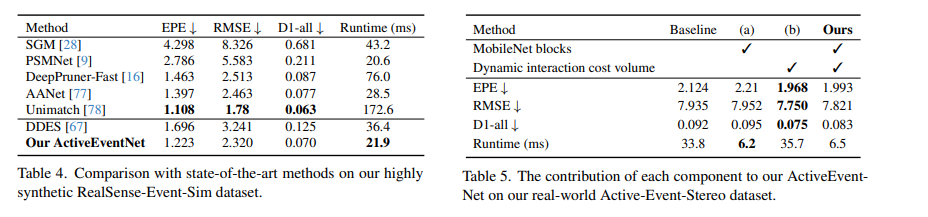

The method is faster than heavier stereo networks while keeping competitive accuracy.



# References

## Textbook / Course Background

[1] R. Szeliski, *Computer Vision: Algorithms and Applications*, 2nd ed., Springer, 2022.  
Used for the basic geometry of stereo vision, camera projection, triangulation, disparity, and 3D reconstruction.

[2] R. Hartley and A. Zisserman, *Multiple View Geometry in Computer Vision*, 2nd ed., Cambridge University Press, 2004.  
Used for camera projection matrices, epipolar geometry, triangulation, and multi-view reconstruction.

[3] S. Savarese and J. Bohg, “Lecture 8: Active Stereo & Volumetric Stereo,” Stanford University CS231A: Computer Vision, From 3D Reconstruction to Recognition, 2025.  
Used as the main lecture reference for active stereo, structured lighting, depth sensing, space carving, shadow carving, voxel coloring, and the assumption of known camera parameters and poses.

## Recent Paper Example

[4] J. Li, Y. Zhang, H. Han, and X. Ji, “Active Event-based Stereo Vision,” in *IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, 2025.  
Used as the recent paper example for active stereo. This work introduces active event-based stereo vision, combining binocular event cameras with infrared structured light, and proposes ActiveEventNet for dense disparity estimation.


## Software / Implementation

[5] OpenCV Library.  
Used for image processing, Gray Code structured light tools, thresholding, rectification, disparity visualization, and morphology operations.
